In [2]:
# Name: Merna Ayman
# SRN: 202201109
# Project: AI-Generated vs Human-Written Text Authenticity Detection

# 0) INSTALL REQUIRED PACKAGES + IMPORT ALL DEPENDENCIES
# Purpose:
#   This cell installs the external dependencies (kagglehub, nltk)
#   and imports all libraries used later in preprocessing, modeling, and evaluation.
# Notes:
#   - All imports are grouped logically (system → data → ML)
#   - No duplicates

# If needed in Colab, install:
# !pip install --quiet pandas numpy scikit-learn matplotlib nltk kagglehub

# 1) Imports
# System & Utilities
import os
import re

# Numerical & Data Handling
import numpy as np
import pandas as pd

import kagglehub # Library used to download datasets directly from Kaggle


from sklearn.model_selection import train_test_split # Split dataset into training and test sets
from sklearn.feature_extraction.text import CountVectorizer # Convert text data into numerical feature vectors
from sklearn.naive_bayes import MultinomialNB # Naive Bayes classifier for text classification
from sklearn.linear_model import LogisticRegression # Logistic Regression model for classification
from sklearn.metrics import (
    accuracy_score, # Measure overall accuracy
    precision_score, # Measure precision
    recall_score, # Measure recall
    f1_score, # Harmonic mean of precision and recall
    confusion_matrix, # Show confusion matrix
    classification_report # Detailed report of all metrics
)

import joblib # Save and load trained ML models
import nltk # Natural Language Toolkit for text processing
from nltk.corpus import stopwords # List of common words to remove during preprocessing

PROJECT OVERVIEW:

• Task: Binary classification (Human vs AI-generated text)

• Dataset: 1,460 essays (94% human, 6% AI - severe imbalance)

• Models: Naive Bayes & Logistic Regression with class weighting

In [3]:
# 2) Load dataset with kagglehub
# Purpose:
# Download and load the "AI Generated Essays" dataset from Kaggle
#   using kagglehub, then read the CSV file into a pandas DataFrame.
# Variables:
#   path : str
#       Local path where the Kaggle dataset folder is downloaded.
#   csv_path : str
#       Full path to the CSV file to load.
#   csv_files : list[str]
#       List of all CSV files detected inside the dataset folder.
#   df : pandas.DataFrame
#       The dataset loaded into memory for preprocessing and analysis.
# Notes:
#   - kagglehub automatically handles downloading.
#   - Program raises an error if no CSV file is found.
# Dataset: denvermagtibay / AI Generated Essays Dataset

# Download the dataset folder from Kaggle
path = kagglehub.dataset_download("denvermagtibay/ai-generated-essays-dataset")
print("Downloaded dataset path:", path)

# The dataset contains a CSV, usually named "AI Generated Essays Dataset.csv".
# We first try that exact name, then fall back to the first CSV in the folder.
csv_path = os.path.join(path, "AI Generated Essays Dataset.csv")
if not os.path.exists(csv_path):
    csv_files = [f for f in os.listdir(path) if f.lower().endswith(".csv")]
    # Safety check — ensure dataset contains a CSV file
    if not csv_files:
        raise FileNotFoundError("No CSV file found in the downloaded dataset folder.")
    csv_path = os.path.join(path, csv_files[0])

print("Using CSV file:", csv_path)

# Load the dataset into a DataFrame
df = pd.read_csv(csv_path)

# Display dataset info
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Using Colab cache for faster access to the 'ai-generated-essays-dataset' dataset.
Downloaded dataset path: /kaggle/input/ai-generated-essays-dataset
Using CSV file: /kaggle/input/ai-generated-essays-dataset/AI Generated Essays Dataset.csv
Dataset shape: (1460, 2)
Columns: ['text', 'generated']


,text,generated
0,"Machine learning, a subset of artificial intel...",1
1,"A decision tree, a prominent machine learning ...",1
2,"Education, a cornerstone of societal progress,...",1
3,"Computers, the backbone of modern technology, ...",1
4,"Chess, a timeless game of strategy and intelle...",1


In [4]:
# 3) Text cleaning / preprocessing
# Purpose:
#   Clean the essay text for modeling by:
#     - converting to lowercase
#     - removing HTML-like tags
#     - keeping only letters and spaces
#     - removing English stopwords
# Variables:
#   stop : set
#       Set of English stopwords from NLTK used for filtering.
#   text : str
#       Original text from the dataset.
#   tokens : list[str]
#       List of words after cleaning and stopword removal.
#   df['clean_text'] : pandas.Series
#       New column containing cleaned text for each essay.
# Notes:
#   - nltk stopwords are downloaded if not already available.
#   - The cleaning function is applied to the 'text' column.
# Download stopwords if not already downloaded
nltk.download('stopwords')

# Use English stopwords for cleaning
stop = set(stopwords.words('english'))

def clean_text(text):
    """
    Clean the input text:
      - convert to lowercase
      - remove HTML-like tags
      - keep only letters and spaces
      - remove English stopwords

    Returns a cleaned string.
    """
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)      # remove HTML tags
    text = re.sub(r'[^a-z\s]', ' ', text)   # keep letters and spaces only
    tokens = [w for w in text.split() if w not in stop]
    return " ".join(tokens)

# Apply cleaning to the 'text' column and store in a new column
df['clean_text'] = df['text'].apply(clean_text)

# Show a quick preview
df[['text', 'clean_text']].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,text,clean_text
0,"Machine learning, a subset of artificial intel...",machine learning subset artificial intelligenc...
1,"A decision tree, a prominent machine learning ...",decision tree prominent machine learning algor...
2,"Education, a cornerstone of societal progress,...",education cornerstone societal progress extend...
3,"Computers, the backbone of modern technology, ...",computers backbone modern technology revolutio...
4,"Chess, a timeless game of strategy and intelle...",chess timeless game strategy intellect transce...


In [5]:
# 4) Train / test split
# Purpose:
#   Split the dataset into training and testing sets for model building and evaluation.
# Variables:
#   X : pandas.Series
#       Features (cleaned text) used for model input.
#   y : pandas.Series
#       Labels (0 = human-written, 1 = AI-generated) for supervised learning.
#   X_train, X_test : pandas.Series
#       Training and testing feature sets.
#   y_train, y_test : pandas.Series
#       Training and testing labels.
# Notes:
#   - 80% of data is used for training, 20% for testing.
#   - Stratified splitting ensures both classes are proportionally represented.
#   - random_state ensures reproducibility.
# Features: cleaned text
X = df['clean_text']

# Labels: 0 = human-written, 1 = AI-generated
y = df['generated']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", len(X_train))
print("Test size :", len(X_test))


Train size: 1168
Test size : 292


In [6]:
# 5) Bag-of-Words representation
# Purpose:
#   Convert cleaned text into numeric features suitable for machine learning models.
# Variables:
#   vectorizer : CountVectorizer
#       Scikit-learn object that transforms text into a Bag-of-Words representation.
#       - max_features=10000 limits the vocabulary to the top 10,000 words/phrases.
#       - ngram_range=(1,2) considers unigrams and bigrams (single words and 2-word sequences).
#   X_train_bow : sparse matrix
#       Numeric feature representation of the training text.
#   X_test_bow : sparse matrix
#       Numeric feature representation of the testing text.
# Notes:
#   - fit_transform is applied on training data to learn the vocabulary and transform it.
#   - transform is applied on testing data using the same learned vocabulary.
#   - Bag-of-Words ignores word order beyond the n-gram length and represents text as counts
vectorizer = CountVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

print("BoW train shape:", X_train_bow.shape)
print("BoW test shape :", X_test_bow.shape)

BoW train shape: (1168, 10000)
BoW test shape : (292, 10000)


In [7]:
# 6) Train models (Naive Bayes & Logistic Regression)
"""
Purpose:
    Train two classification models (Naive Bayes and Logistic Regression)
    to predict whether a text is human-written or AI-generated

Variables:
    nb_model (MultinomialNB): Naive Bayes classifier for text data
    lr_model (LogisticRegression): Logistic Regression classifier
    X_train_bow (sparse matrix): Bag-of-Words features for training data
    y_train (pd.Series): Target labels for training data
"""
# Multinomial Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_bow, y_train)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_bow, y_train)

print("Models trained successfully:)")

Models trained successfully:)


EVALUATING MODELS ON TEST SET
=== Naive Bayes ===
Accuracy : 0.9931506849315068
Precision: 1.0
Recall   : 0.8823529411764706
F1-score : 0.9375

Classification report:
              precision    recall  f1-score   support

       Human       0.99      1.00      1.00       275
          AI       1.00      0.88      0.94        17

    accuracy                           0.99       292
   macro avg       1.00      0.94      0.97       292
weighted avg       0.99      0.99      0.99       292


ROC Curve Analysis:
  • AUC Score: 0.9957
  • Optimal threshold: 0.000
  • At optimal threshold:
    - True Positive Rate (Recall): 0.941
    - False Positive Rate: 0.000

Performance at optimal threshold (0.000):
  Accuracy : 0.9966
  Precision: 1.0000
  Recall   : 0.9412
  F1-score : 0.9697


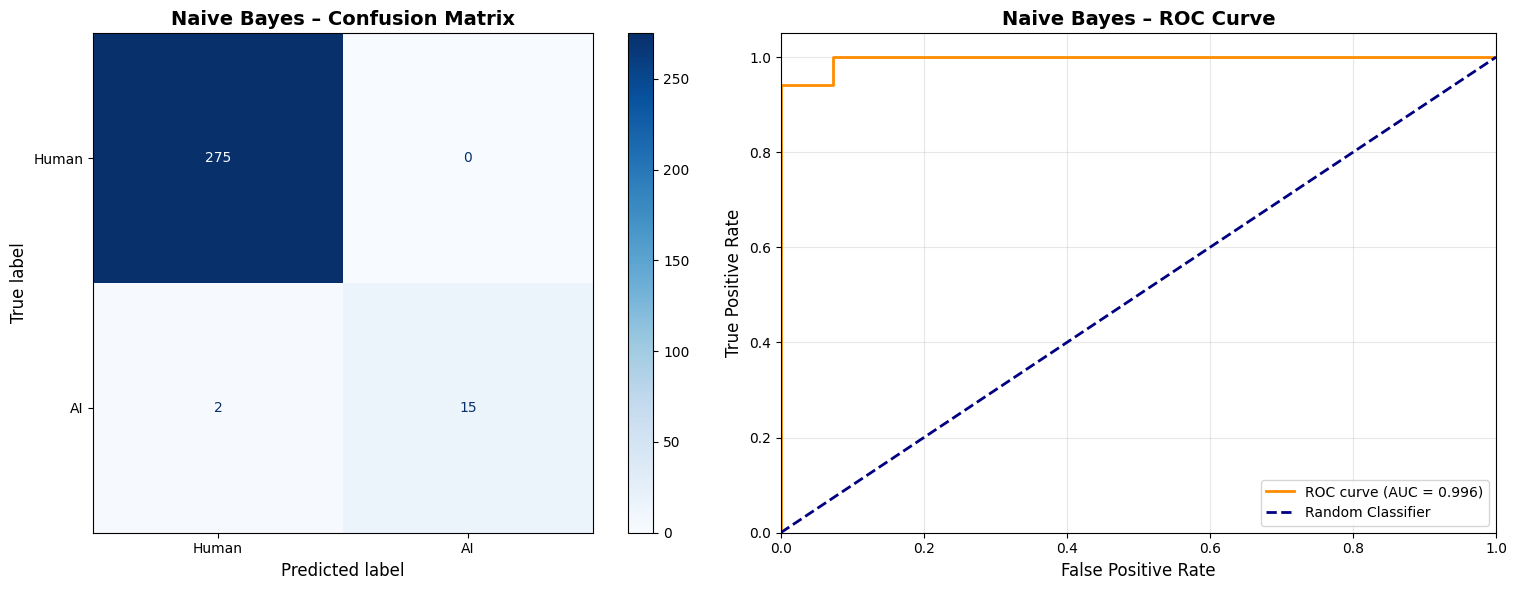



=== Logistic Regression ===
Accuracy : 0.9931506849315068
Precision: 1.0
Recall   : 0.8823529411764706
F1-score : 0.9375

Classification report:
              precision    recall  f1-score   support

       Human       0.99      1.00      1.00       275
          AI       1.00      0.88      0.94        17

    accuracy                           0.99       292
   macro avg       1.00      0.94      0.97       292
weighted avg       0.99      0.99      0.99       292


ROC Curve Analysis:
  • AUC Score: 0.9966
  • Optimal threshold: 0.001
  • At optimal threshold:
    - True Positive Rate (Recall): 1.000
    - False Positive Rate: 0.058

Performance at optimal threshold (0.001):
  Accuracy : 0.9452
  Precision: 0.5152
  Recall   : 1.0000
  F1-score : 0.6800


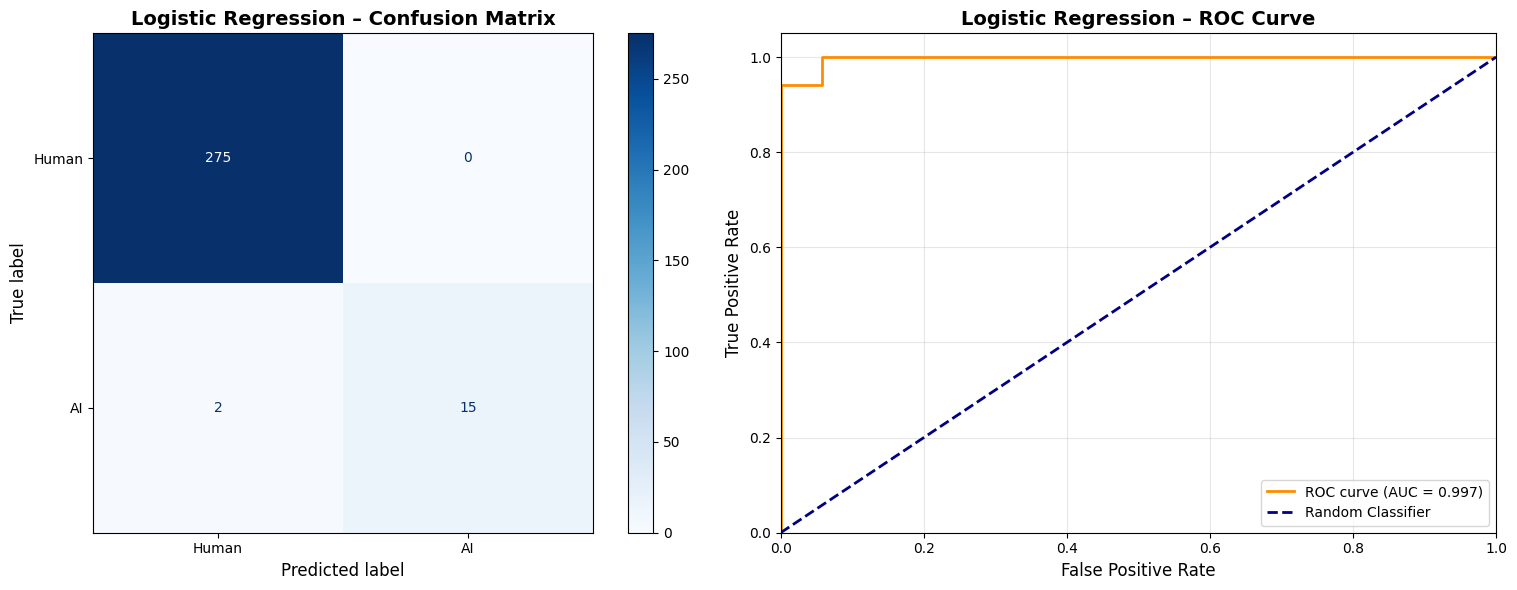

In [8]:
# 7) Enhanced Evaluation helper with ROC Curve
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

def eval_model(model, X_test, y_test, name="Model"):
    """
    Evaluate a model on the test set and show:
      - Accuracy, Precision, Recall, F1-score
      - Classification report
      - Confusion matrix heatmap (Human vs AI)
      - ROC Curve with AUC score (NEW)
    """
    preds = model.predict(X_test)

    # ---- Print the metrics ----
    print(f"=== {name} ===")
    print("Accuracy :", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("Recall   :", recall_score(y_test, preds))
    print("F1-score :", f1_score(y_test, preds))

    print("\nClassification report:")
    print(classification_report(y_test, preds, target_names=["Human", "AI"]))

    # Confusion Matrix as an image
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Confusion Matrix
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test,
        preds,
        display_labels=["Human", "AI"],
        cmap="Blues",
        colorbar=True,
        ax=axes[0]
    )
    axes[0].set_title(f"{name} – Confusion Matrix", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Predicted label", fontsize=12)
    axes[0].set_ylabel("True label", fontsize=12)

    # ROC Curve
    # Check if model can predict probabilities
    if hasattr(model, 'predict_proba'):
        # Get probabilities for the AI class (class 1)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate ROC curve and AUC
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
        roc_auc = roc_auc_score(y_test, y_pred_proba)

        # Plot ROC curve
        axes[1].plot(fpr, tpr, color='darkorange', lw=2,
                    label=f'ROC curve (AUC = {roc_auc:.3f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
                    label='Random Classifier')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate', fontsize=12)
        axes[1].set_ylabel('True Positive Rate', fontsize=12)
        axes[1].set_title(f'{name} – ROC Curve', fontsize=14, fontweight='bold')
        axes[1].legend(loc="lower right")
        axes[1].grid(True, alpha=0.3)

        # Find optimal threshold (Youden's J statistic)
        optimal_idx = np.argmax(tpr - fpr)
        optimal_threshold = thresholds[optimal_idx]

        print(f"\nROC Curve Analysis:")
        print(f"  • AUC Score: {roc_auc:.4f}")
        print(f"  • Optimal threshold: {optimal_threshold:.3f}")
        print(f"  • At optimal threshold:")
        print(f"    - True Positive Rate (Recall): {tpr[optimal_idx]:.3f}")
        print(f"    - False Positive Rate: {fpr[optimal_idx]:.3f}")

        # Calculate predictions at optimal threshold
        y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

        print(f"\nPerformance at optimal threshold ({optimal_threshold:.3f}):")
        print(f"  Accuracy : {accuracy_score(y_test, y_pred_optimal):.4f}")
        print(f"  Precision: {precision_score(y_test, y_pred_optimal):.4f}")
        print(f"  Recall   : {recall_score(y_test, y_pred_optimal):.4f}")
        print(f"  F1-score : {f1_score(y_test, y_pred_optimal):.4f}")

    else:
        # If model doesn't support predict_proba, show message
        axes[1].text(0.5, 0.5, f'{name} does not support\nprobability predictions',
                    ha='center', va='center', fontsize=12)
        axes[1].set_title(f'{name} – ROC Curve (Not Available)', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('False Positive Rate', fontsize=12)
        axes[1].set_ylabel('True Positive Rate', fontsize=12)
        axes[1].grid(True, alpha=0.3)
        print("\nNote: This model does not support probability predictions for ROC analysis.")

    plt.tight_layout()
    plt.show()
    print("\n" + "="*70 + "\n")

# Run evaluations
print("EVALUATING MODELS ON TEST SET")
print("="*70)
eval_model(nb, X_test_bow, y_test, "Naive Bayes")
eval_model(lr, X_test_bow, y_test, "Logistic Regression")


In [ ]:
# 8) Save trained models & vectorizer
# Save the trained Naive Bayes model
joblib.dump(
    nb,                     # trained Naive Bayes classifier
    "naive_bayes_model.joblib"
)

# Save the trained Logistic Regression model
joblib.dump(
    lr,                     # trained Logistic Regression classifier
    "logistic_regression_model.joblib"
)

# Save the CountVectorizer used for BoW features
joblib.dump(
    vectorizer,             # fitted CountVectorizer
    "vectorizer.joblib"
)

print("Models and vectorizer saved to .joblib files.")


Models and vectorizer saved to .joblib files.


In [ ]:
# 9) Prediction function + one unseen example

def predict_text(text, model, vectorizer):
    """
    Predict whether a given text is human-written or AI-generated.

    Parameters:
        text (str): raw input text.
        model: trained classifier (Naive Bayes or Logistic Regression).
        vectorizer: fitted CountVectorizer.

    Returns:
        int: predicted label (0 = human, 1 = AI-generated).
    """
    # Step 1: Clean and preprocess the input text
    cleaned_text = clean_text(text)
    text_vec = vectorizer.transform([cleaned_text])
    prediction = model.predict(text_vec)[0]
    return prediction

# Use one sample from the test set as an "unseen" example
sample_text = X_test.iloc[0]
actual_label = y_test.iloc[0]
predicted_label = predict_text(sample_text, lr, vectorizer)

print("=== Prediction on ONE unseen test sample ===")
print("Text snippet:", sample_text[:300], "...")
print("Predicted Label:", predicted_label)
print("Actual Label:", actual_label)

=== Prediction on ONE unseen test sample ===
Text snippet: imagine world without garages stations parkinglots problem today world lives revolve around cars get us want become status symbol many thought without car scares people limiting car usage becoming popular cities shown many advantages environment communities example residents vauban germany given car ...
Predicted Label: 0
Actual Label: 0
